# « Développez une preuve de concept »

Projet n&#8239;$^\text{o}$ 7 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 18/05/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

# Notebook d’entraînement du modèle *baseline* `EfficientNetB0` sur 120 classes

Le dataset : http://vision.stanford.edu/aditya86/ImageNetDogs/

## Imports et constantes

In [16]:
DEFAULT_TRGT_IMG_SIZE = (224, 224)
DEFAULT_BATCH_SIZE = 8

import os
# Déclarer le backend avant d'importer keras (sinon par défaut c'est 'tensorflow'):
os.environ["KERAS_BACKEND"] = "torch"
# Memory optimization: Enable expandable segments to reduce fragmentation:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# Limiter la verbosité des logs de tensorflow:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from functions_model_building import (
    BREED_ID_SPLITTER_REGEX_PTRN,
    build_model_from_pretrained,
    MyF1Metric,
    MyKerasSequence,
    plot_accuracy_and_loss_values,
    plot_confusion_matrix,
)
import torch
import keras
# Memory optimization: Use mixed precision (if GPU supports it):
keras.mixed_precision.set_global_policy('mixed_float16')

from keras.applications.efficientnet import EfficientNetB0
from keras.applications.efficientnet_v2 import EfficientNetV2B0
from keras.applications.vgg16 import VGG16
from keras.metrics import SparseTopKCategoricalAccuracy

from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datetime as dt
import joblib
import itertools as it
import numpy as np
import pandas as pd
import pytz
import sys
import time

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

LOGGER_FORMAT = '%(asctime)s [%(levelname)s] %(message)s'
logging.Formatter.converter = lambda *_: dt.datetime.now(pytz.timezone('Europe/Paris')).timetuple()
logging.basicConfig(level=logging.INFO, format=LOGGER_FORMAT, force=True)
logr = logging.getLogger(__name__)
logr.setLevel(logging.DEBUG)

## Split train - val - test

In [17]:
input_img_paths = tuple(
    # [Path('images/n02090379-redbone'), Path('images/n02085936-Maltese_dog'), Path('images/n02088094-Afghan_hound')]
    Path('images/').glob('*/')
)
logr.info(f"Nombre de classes retenues pour l'entraînement : {len(input_img_paths)}")
input_img_paths = tuple(path.glob('*.jpg') for path in input_img_paths)
input_img_paths = tuple(it.chain.from_iterable(input_img_paths))
logr.info(f"Résultat : un tuple de {len(input_img_paths)} images pour les 3 classes de races.")
breed_labels = tuple(str(path).split('/')[1] for path in input_img_paths)
breed_labels_encoded = LabelEncoder().fit_transform(breed_labels)
breed_labels_dict = dict(sorted(zip(breed_labels_encoded, breed_labels)))
n = 1000
logr.info(f"Un échantillon de la distribution des classes (seuls les {n} premiers chemins sont comptés) :")
display(dict(Counter(breed_labels[:n])))
train_frac = 0.8
input_paths_train, input_paths_val_test, labels_train, labels_val_test = train_test_split(
    input_img_paths, breed_labels, train_size=train_frac,
    random_state=42, shuffle=True, stratify=breed_labels,
)
val_test_frac = 0.5
input_paths_val, input_paths_test, labels_val, labels_test = train_test_split(
    input_paths_val_test, labels_val_test, train_size=val_test_frac,
    random_state=42, shuffle=True, stratify=labels_val_test
)
del input_paths_val_test, labels_val_test, n
logr.info(f"Taile de l'échantillon de train ({train_frac}): {len(input_paths_train)}")
logr.info(f"Taile de l'échantillon de val ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_val)}")
logr.info(f"Taile de l'échantillon de test ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_test)}")

2026-06-15 10:42:47,920 [INFO] Nombre de classes retenues pour l'entraînement : 120
2026-06-15 10:42:47,983 [INFO] Résultat : un tuple de 20580 images pour les 3 classes de races.
2026-06-15 10:42:48,005 [INFO] Un échantillon de la distribution des classes (seuls les 1000 premiers chemins sont comptés) :


{'n02105251-briard': 152,
 'n02100583-vizsla': 154,
 'n02104029-kuvasz': 150,
 'n02086910-papillon': 196,
 'n02116738-African_hunting_dog': 169,
 'n02111500-Great_Pyrenees': 179}

2026-06-15 10:42:48,045 [INFO] Taile de l'échantillon de train (0.8): 16464
2026-06-15 10:42:48,046 [INFO] Taile de l'échantillon de val (0.1): 2058
2026-06-15 10:42:48,047 [INFO] Taile de l'échantillon de test (0.1): 2058


## Entraînement

Déclarer les paramètres :

In [18]:
PRTR_MDL = EfficientNetB0
FT = 'block7'
PREPROCESSING_FUNC = keras.applications.efficientnet.preprocess_input
train_seq = MyKerasSequence(input_paths_train, labels_train, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
val_seq = MyKerasSequence(input_paths_val, labels_val, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
test_seq = MyKerasSequence(input_paths_test, labels_test, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
N_CLASSES = len(input_img_paths)
TOP_K_CATEG_ACC = 5
N_EPOCHS = 20
DROPOUT_RATE = 0.2
LR = 1e-5  # learning rate doit être faible !
experiment_name = f'CNN__from={PRTR_MDL.__name__}__FT={FT}__n_cls={N_CLASSES}__n_eps={N_EPOCHS}__drpt={DROPOUT_RATE:.2f}__LR={LR}'

Construire le modèle :

In [19]:
model = build_model_from_pretrained(
    pretrained_model=PRTR_MDL,
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    layers_to_finetune=FT,
    experiment_name=experiment_name
)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        SparseTopKCategoricalAccuracy(TOP_K_CATEG_ACC),
        MyF1Metric(average='macro', name='f1_macro')
    ],
)
display(
    # model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Entraînement et validation :

In [20]:
torch.cuda.empty_cache()

2026-06-15 10:42:50,338 [INFO] Entraînement du modèle 'CNN__from=EfficientNetB0__FT=block7__n_cls=20580__n_eps=20__drpt=0.20__LR=1e-05'...
W0000 00:00:1781512981.522914   52383 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-06-15 13:19:09,842 [INFO] Entraînement du modèle 'CNN__from=EfficientNetB0__FT=block7__n_cls=20580__n_eps=20__drpt=0.20__LR=1e-05' terminé
2026-06-15 13:19:09,842 [INFO] Sauvegarder l'objet 'models/CNN__from=EfficientNetB0__FT=block7__n_cls=20580__n_eps=20__drpt=0.20__LR=1e-05_model.keras'
2026-06-15 13:19:11,354 [INFO] Sauvegarder l'objet 'models/CNN__from=EfficientNetB0__FT=block7__n_cls=20580__n_eps=20__drpt=0.20__LR=1e-05_history.joblib'


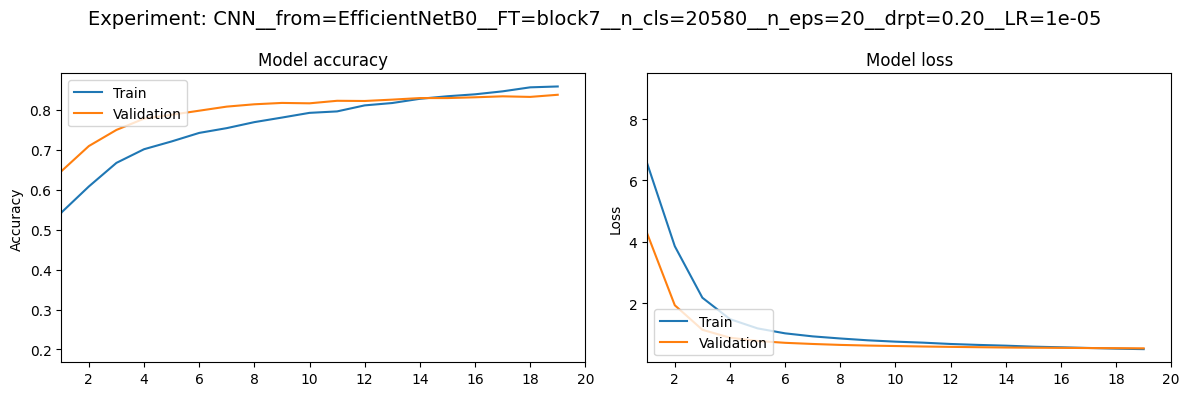

2026-06-15 13:19:13,510 [INFO] Précision finale de l'entraînement: 0.8580
2026-06-15 13:19:13,522 [INFO] Précision finale de la validation: 0.8372
2026-06-15 13:19:13,523 [INFO] Loss finale de l'entraînement: 0.5036
2026-06-15 13:19:13,523 [INFO] Loss finale de la validation: 0.5303


In [21]:
path_to_model = f'models/{experiment_name}_model.keras'
path_to_history = f'models/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location={'accuracy': 'upper left', 'loss': 'lower left'})
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

## Évaluation sur les données de test

2026-06-15 13:19:13,530 [INFO] Évaluation sur les données de test :


258/258 ━━━━━━━━━━━━━━━━━━━━ 61s 237ms/step - accuracy: 0.8353 - f1_macro: 0.8300 - loss: 0.5416 - sparse_top_k_categorical_accuracy: 0.9869


2026-06-15 13:20:14,793 [INFO] loss, accuracy = [0.5415905714035034, 0.8352769613265991, 0.9868804812431335, 0.8299659842837956]


258/258 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step


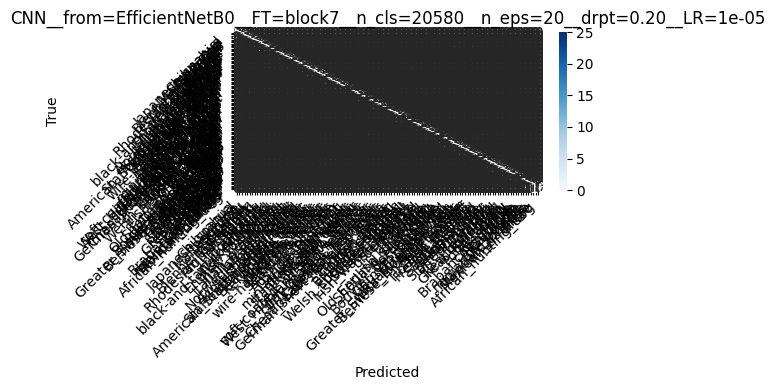

In [22]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")
plot_confusion_matrix(model, test_seq, test_seq.yset, breed_labels_dict.values(), title=f'{experiment_name}')

## Prédiction en mode *blind test*

Effectuer l'inférence :

In [23]:
DEFAULT_BLIND_TEST_SAMPLE_SIZE = 100
blind_test_sample = np.random.choice(input_img_paths, size=DEFAULT_BLIND_TEST_SAMPLE_SIZE, replace=False)
blind_test_seq = MyKerasSequence(
    paths=blind_test_sample,
    labels=[''] * len(blind_test_sample),
    batch_size=DEFAULT_BATCH_SIZE,
    target_size=DEFAULT_TRGT_IMG_SIZE,
    preprocessing_func=keras.applications.efficientnet.preprocess_input
)
start_time = time.perf_counter()
predictions = model.predict(blind_test_seq)
end_time = time.perf_counter()
print(f"Inference time: {end_time - start_time:.2f}s")
predicted_class_idx = np.argmax(predictions, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step
Inference time: 4.20s


Afficher les résultats sous une forme conviviale :

In [24]:
df = pd.DataFrame({
    'path': blind_test_sample,
    'predicted_breed': [BREED_ID_SPLITTER_REGEX_PTRN.split(breed_labels_dict[class_idx])[1]
                        for class_idx in predicted_class_idx]
}, dtype=str)
df['is_correct'] = df.apply(
    lambda row: '✅' if row['predicted_breed'] in row['path'] else '❗️',
    axis=1
)
default_max_rows = pd.options.display.max_rows
pd.options.display.max_rows = DEFAULT_BLIND_TEST_SAMPLE_SIZE
display(df)
pd.options.display.max_rows = default_max_rows

,path,predicted_breed,is_correct
0,images/n02105056-groenendael/n02105056_7291.jpg,groenendael,✅
1,images/n02102973-Irish_water_spaniel/n02102973...,Irish_water_spaniel,✅
2,images/n02085620-Chihuahua/n02085620_5713.jpg,Pomeranian,❗️
3,images/n02105412-kelpie/n02105412_1222.jpg,kelpie,✅
4,images/n02105162-malinois/n02105162_6625.jpg,malinois,✅
5,images/n02099429-curly-coated_retriever/n02099...,curly-coated_retriever,✅
6,images/n02085936-Maltese_dog/n02085936_10073.jpg,Maltese_dog,✅
7,images/n02106550-Rottweiler/n02106550_5710.jpg,Rottweiler,✅
8,images/n02096294-Australian_terrier/n02096294_...,Australian_terrier,✅
9,images/n02113799-standard_poodle/n02113799_196...,standard_poodle,✅
